### 2 Conversion Rate +

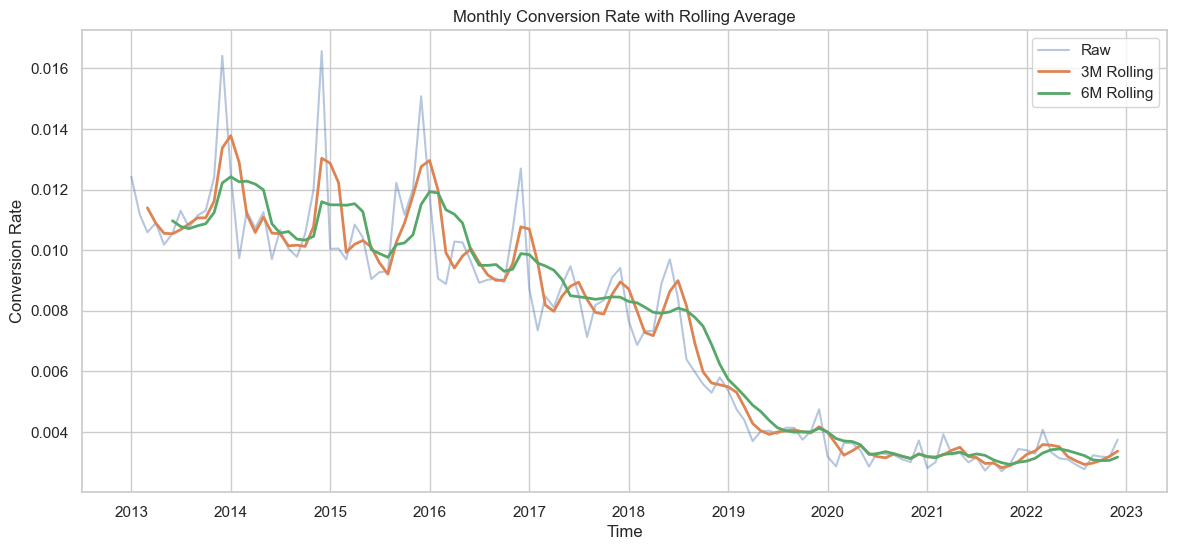

In [2]:
# Monthly conversion + rolling 3M & 6M
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
traffic = pd.read_csv("data/web_traffic.csv", parse_dates=["date"])

# Align thời gian
start_date = traffic["date"].min()
orders = orders[orders["order_date"] >= start_date].copy()

# Tạo month
orders["month"] = orders["order_date"].dt.to_period("M")
traffic["month"] = traffic["date"].dt.to_period("M")

# Aggregate
monthly_orders = orders.groupby("month").size().rename("orders")
monthly_sessions = traffic.groupby("month")["sessions"].sum().rename("sessions")

df = pd.concat([monthly_orders, monthly_sessions], axis=1).fillna(0)

# Conversion rate
df["conversion_rate"] = df["orders"] / df["sessions"]

# Rolling
df["cr_3m"] = df["conversion_rate"].rolling(3).mean()
df["cr_6m"] = df["conversion_rate"].rolling(6).mean()

# Convert index sang datetime để plot đẹp
df.index = df.index.to_timestamp()

# Visualization
plt.figure(figsize=(14, 6))

# Raw
plt.plot(df.index, df["conversion_rate"], label="Raw", alpha=0.4)

# Rolling
plt.plot(df.index, df["cr_3m"], label="3M Rolling", linewidth=2)
plt.plot(df.index, df["cr_6m"], label="6M Rolling", linewidth=2)

plt.title("Monthly Conversion Rate with Rolling Average")
plt.xlabel("Time")
plt.ylabel("Conversion Rate")

plt.legend()
plt.show()

Conversion rate = (tổng order 1 tháng) / (session 1 tháng)
- orders.csv và web_traffic.csv không có chung 1 mốc bắt đầu nên ta sẽ phải cắt đi tất cả các order trước 2013-1-1 ( điểm bắt đầu của web_traffic ) để tính conversion_rate 
- sau khi quan sát ta chia ra thành 2 mốc 
    - Trước 2019: 
    raw: biến động lên xuống mạnh mẽ, nhưng khá có tính chu kì, tăng mạnh ở những tháng cuối năm nhưng giảm liên tục đến đầu năm sau đó rồi lại bình ổn đến cuối năm 
    3m và 6m: tương tự có tính biến động chu kì như vậy nhưng đến 2017 có xu hướng đi xuống rõ rệt
    - Sau 2019: cả 3 đường đều giảm theo U-shape
> Như vậy chuyện sụp đổ ở 2019 có lẽ không phải là đột ngột, đó chỉ là hệ quả âm thầm từ 2017-2018

- hơn hết ta thấy conversion rate rất thấp, max 1.6% min 0.4%

### 4 Ngưỡng chịu đựng của khách hàng

#### 4.1 Ngưỡng chịu đựng đối với late delivery

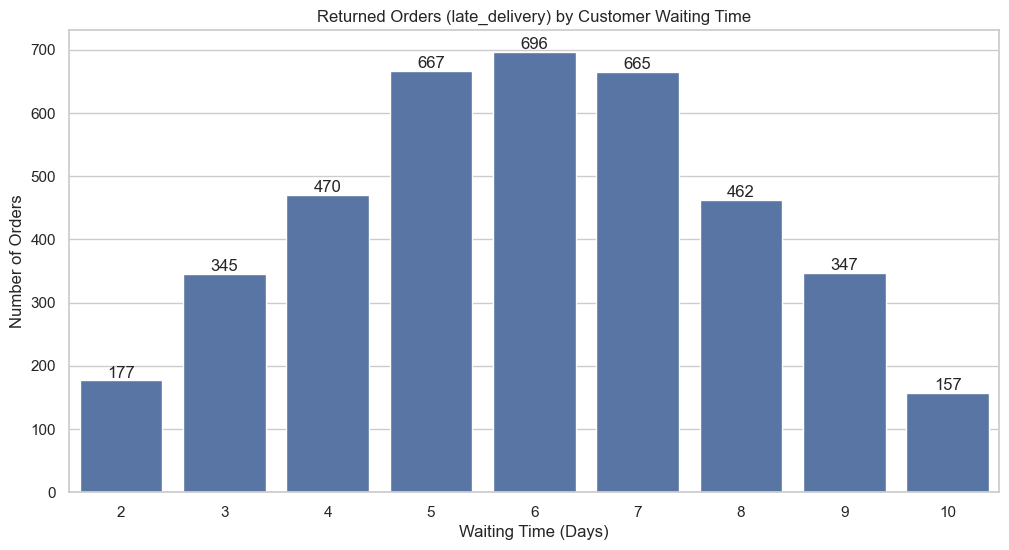

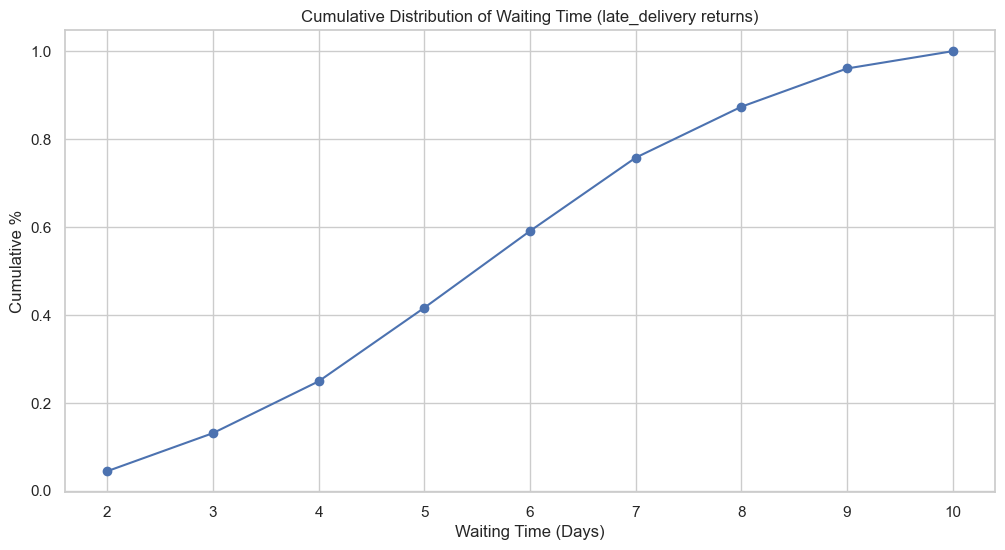

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load data
orders = pd.read_csv("data/orders.csv", parse_dates=["order_date"])
shipments = pd.read_csv("data/shipments.csv", parse_dates=["ship_date", "delivery_date"])
returns = pd.read_csv("data/returns.csv")

df = orders.merge(shipments, on="order_id", how="inner")
df = df.merge(returns, on="order_id", how="inner")

df = df[
    (df["order_status"] == "returned") &
    (df["return_reason"] == "late_delivery")
].copy()

df["waiting_days"] = (df["delivery_date"] - df["order_date"]).dt.days

# clean data
df = df[df["waiting_days"] >= 0]

waiting_dist = df["waiting_days"].value_counts().sort_index()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=waiting_dist.index,
    y=waiting_dist.values
)

for i, v in enumerate(waiting_dist.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Returned Orders (late_delivery) by Customer Waiting Time")
plt.xlabel("Waiting Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

cum_dist = waiting_dist.cumsum() / waiting_dist.sum()

plt.figure(figsize=(12,6))

cum_dist.plot(marker='o')

plt.title("Cumulative Distribution of Waiting Time (late_delivery returns)")
plt.xlabel("Waiting Time (Days)")
plt.ylabel("Cumulative %")

plt.show()

Trong bộ dữ liệu chúng ta không có những cột như expect_delivery_date hay các kì vọng tương tự
> Ta sẽ xem như khoảng thời gian khách hàng chịu đựng tính từ *order_date* cho đến *delivery_date*
Như vậy Distribution đối với khoảng thời gian này có hình tam giác với đỉnh là 6.
Nhưng ta nên nhìn vào biểu đồ Cummulative ( ngưỡng tích lũy ) đối với các khách hàng trả lại, ta thấy **50%** khách hàng sẽ trả lại hàng nếu như thời *waiting time* = 5

#### 4.2 Return rate

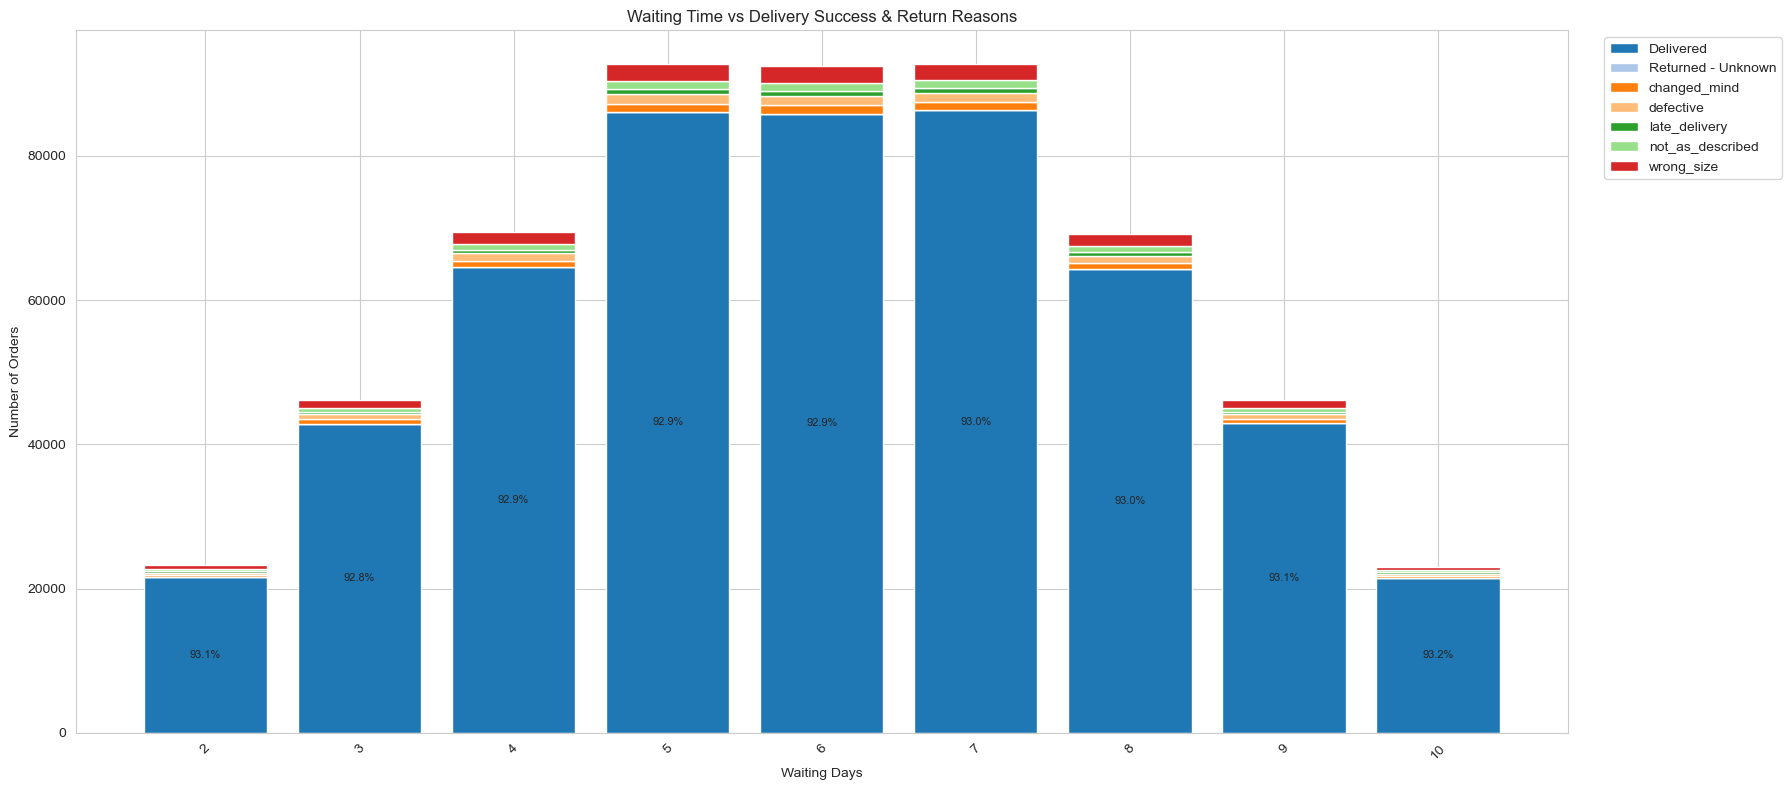

In [7]:
# ===== Waiting Time vs Delivery Outcome (Fixed version) =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
orders = pd.read_csv("data/orders.csv")
shipments = pd.read_csv("data/shipments.csv")
returns = pd.read_csv("data/returns.csv")

# Parse dates
orders["order_date"] = pd.to_datetime(orders["order_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])

orders_f = orders[orders["order_status"].isin(["delivered", "returned"])].copy()
df = orders_f.merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
df = df.merge(returns[["order_id", "return_reason"]], on="order_id", how="left")
df["wait_days"] = (df["delivery_date"] - df["order_date"]).dt.days
df = df[df["wait_days"].notna() & (df["wait_days"] >= 0)]
df["wait_days"] = df["wait_days"].astype(int)
df["outcome"] = np.where(
    df["order_status"] == "delivered",
    "Delivered",
    df["return_reason"].fillna("Returned - Unknown")
)
plot_df = df.groupby(["wait_days", "outcome"])["order_id"].nunique().reset_index(name="order_count")

pivot_counts = plot_df.pivot(index="wait_days", columns="outcome", values="order_count").fillna(0)
cols = pivot_counts.columns.tolist()
return_cols = sorted([c for c in cols if c != "Delivered"])
pivot_counts = pivot_counts[["Delivered"] + return_cols]

# % per column
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(18,8))

x = np.arange(len(pivot_counts.index))
bottom = np.zeros(len(pivot_counts))

palette = sns.color_palette("tab20", len(pivot_counts.columns))

for i, col in enumerate(pivot_counts.columns):
    values = pivot_counts[col].values
    
    bars = ax.bar(
        x, values, bottom=bottom,
        label=col,
        color=palette[i],
        edgecolor='white'
    )

    # annotate %
    pct_vals = pivot_pct[col].values
    for j, (bar, pct) in enumerate(zip(bars, pct_vals)):
        if pct >= 5:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom[j] + values[j]/2,
                f"{pct:.1f}%",
                ha='center', va='center', fontsize=8
            )

    bottom += values

# Axis
labels = pivot_counts.index.astype(str)
if len(labels) > 30:
    step = len(labels)//20
    ax.set_xticks(x[::step])
    ax.set_xticklabels(labels[::step], rotation=45)
else:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)

ax.set_title("Waiting Time vs Delivery Success & Return Reasons")
ax.set_xlabel("Waiting Days")
ax.set_ylabel("Number of Orders")
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

Ta sẽ xem xét tổng quan các đơn hàng và theo *waiting_days* = *delivery_date* - *order_date*
Vì tỉ lệ giao hàng thành công ~93% làm lu mờ đi cũng như khó hiển thị nguyên nhân tại sao đơn hàng bị return, ta sẽ xét riêng các đơn hàng bị return

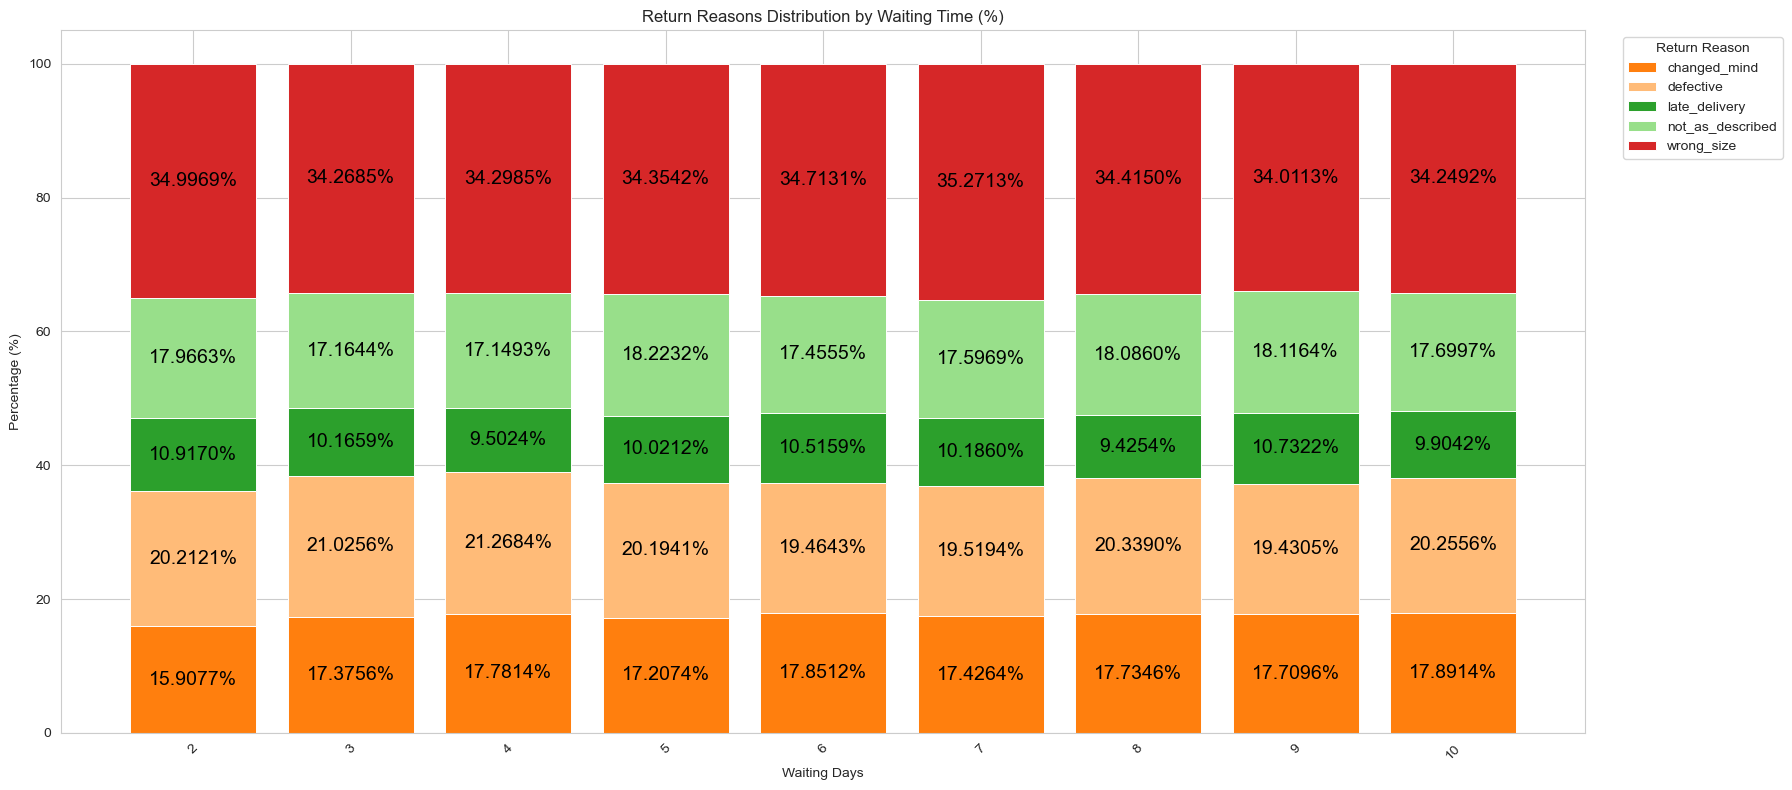

In [8]:
# ===== Return Analysis by Waiting Time (match colors with previous cell) =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
orders = pd.read_csv("data/orders.csv")
shipments = pd.read_csv("data/shipments.csv")
returns = pd.read_csv("data/returns.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"])

orders_f = orders[orders["order_status"].isin(["delivered", "returned"])].copy()
df_all = orders_f.merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
df_all = df_all.merge(returns[["order_id", "return_reason"]], on="order_id", how="left")

df_all["wait_days"] = (df_all["delivery_date"] - df_all["order_date"]).dt.days
df_all = df_all[df_all["wait_days"].notna() & (df_all["wait_days"] >= 0)].copy()
df_all["wait_days"] = df_all["wait_days"].astype(int)

df_all["outcome"] = np.where(
    df_all["order_status"] == "delivered",
    "Delivered",
    df_all["return_reason"].fillna("Returned - Unknown")
)

plot_df_all = (
    df_all.groupby(["wait_days", "outcome"])["order_id"]
          .nunique()
          .reset_index(name="order_count")
)

pivot_all = plot_df_all.pivot(index="wait_days", columns="outcome", values="order_count").fillna(0)

all_cols = pivot_all.columns.tolist()
return_cols = sorted([c for c in all_cols if c != "Delivered"])
ordered_cols = (["Delivered"] if "Delivered" in all_cols else []) + return_cols
pivot_all = pivot_all[ordered_cols]

palette_all = sns.color_palette("tab20", len(pivot_all.columns))
color_map = dict(zip(pivot_all.columns, palette_all))

orders_r = orders[orders["order_status"] == "returned"].copy()

df = orders_r.merge(shipments[["order_id", "delivery_date"]], on="order_id", how="inner")
df = df.merge(returns[["order_id", "return_reason"]], on="order_id", how="left")

df["wait_days"] = (df["delivery_date"] - df["order_date"]).dt.days
df = df[df["wait_days"].notna() & (df["wait_days"] >= 0)].copy()
df["wait_days"] = df["wait_days"].astype(int)

plot_df = (
    df.groupby(["wait_days", "return_reason"])["order_id"]
      .nunique()
      .reset_index(name="count")
)

pivot = plot_df.pivot(index="wait_days", columns="return_reason", values="count").fillna(0)

matched_return_cols = [c for c in return_cols if c in pivot.columns]
extra_cols = [c for c in pivot.columns if c not in matched_return_cols]
pivot = pivot[matched_return_cols + extra_cols]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(18, 8))

x = np.arange(len(pivot_pct.index))
bottom = np.zeros(len(pivot_pct))

for col in pivot_pct.columns:
    heights = pivot_pct[col].values
    bars = ax.bar(
        x,
        heights,
        bottom=bottom,
        label=col,
        color=color_map.get(col, "gray"),   
        edgecolor="white",
        linewidth=0.7
    )

    for i, (bar, h) in enumerate(zip(bars, heights)):
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + h / 2,
                f"{h:.4f}%",
                ha="center",
                va="center",
                fontsize=14,
                color="black"
            )

    bottom += heights

# Tick labels
labels = pivot_pct.index.astype(str).tolist()
if len(labels) > 30:
    step = max(1, len(labels) // 20)
    ax.set_xticks(x[::step])
    ax.set_xticklabels(labels[::step], rotation=45)
else:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)

ax.set_title("Return Reasons Distribution by Waiting Time (%)")
ax.set_xlabel("Waiting Days")
ax.set_ylabel("Percentage (%)")
ax.legend(title="Return Reason", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### 4.3 Đơn hàng bị trả lại nhiều hơn 1 lần

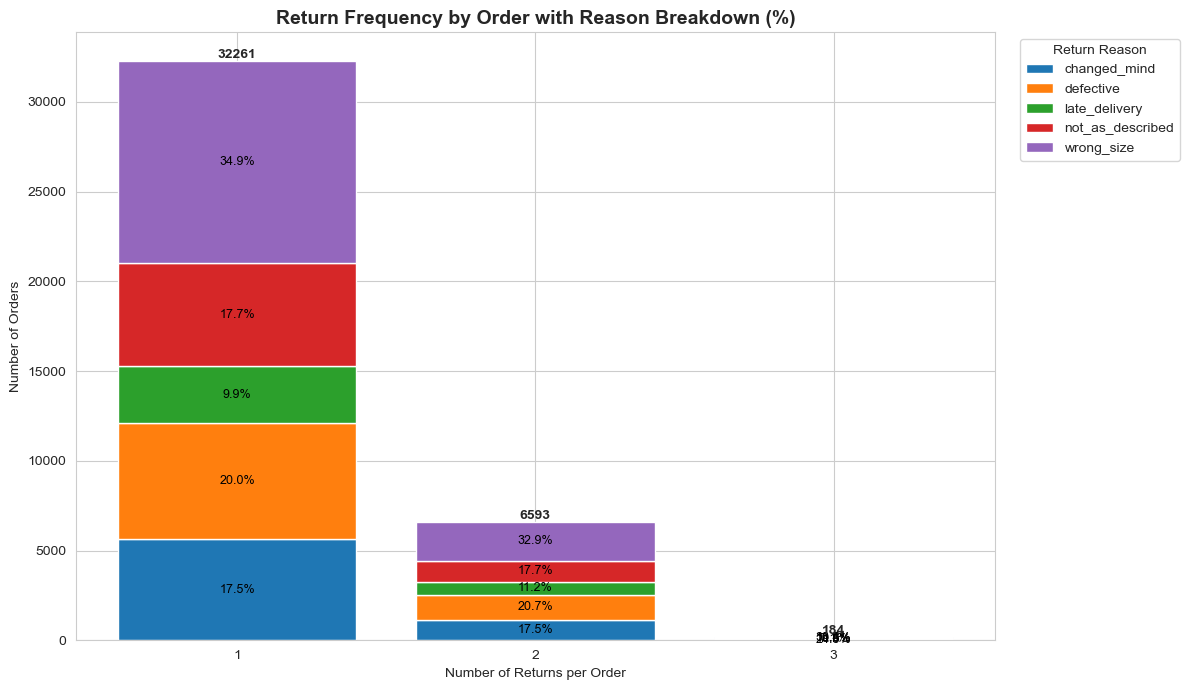

In [3]:
# ===== Return frequency with reason breakdown (%) =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
returns = pd.read_csv('data/returns.csv')

# --------------------------------------------------
# 1. Số lần return theo order
# --------------------------------------------------
return_counts = returns.groupby('order_id').agg(
    num_returns=('return_id', 'nunique')
).reset_index()

# --------------------------------------------------
# 2. Gắn num_returns vào từng dòng return
# --------------------------------------------------
df = returns.merge(return_counts, on='order_id', how='left')

# --------------------------------------------------
# 3. Đếm số order theo (num_returns, return_reason)
# --------------------------------------------------
# Mỗi order chỉ tính 1 lần cho mỗi reason → drop_duplicates
df_unique = df[['order_id', 'num_returns', 'return_reason']].drop_duplicates()

agg = df_unique.groupby(['num_returns', 'return_reason']).size().reset_index(name='count')

# Pivot
pivot = agg.pivot(index='num_returns', columns='return_reason', values='count').fillna(0)

# Tổng số order theo num_returns
total_orders = pivot.sum(axis=1)

# % theo từng reason
pivot_pct = pivot.div(total_orders, axis=0) * 100

# --------------------------------------------------
# 4. Plot
# --------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12,7))

x = np.arange(len(pivot.index))
bottom = np.zeros(len(pivot))

# Màu consistent
palette = sns.color_palette("tab10", len(pivot.columns))

for i, col in enumerate(pivot.columns):
    values = pivot[col].values
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=palette[i],
        label=col,
        edgecolor='white'
    )

    # Annotate % (ở giữa mỗi segment)
    pct_vals = pivot_pct[col].values
    for j, (bar, pct) in enumerate(zip(bars, pct_vals)):
        if pct > 3:  # tránh quá rối
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom[j] + values[j]/2,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

    bottom += values

# --------------------------------------------------
# 5. Tổng số order trên đỉnh cột
# --------------------------------------------------
for i, total in enumerate(total_orders):
    ax.text(i, total, f"{int(total)}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# --------------------------------------------------
# 6. Format
# --------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)

ax.set_xlabel("Number of Returns per Order")
ax.set_ylabel("Number of Orders")
ax.set_title("Return Frequency by Order with Reason Breakdown (%)", fontsize=14, fontweight='bold')

ax.legend(title="Return Reason", bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

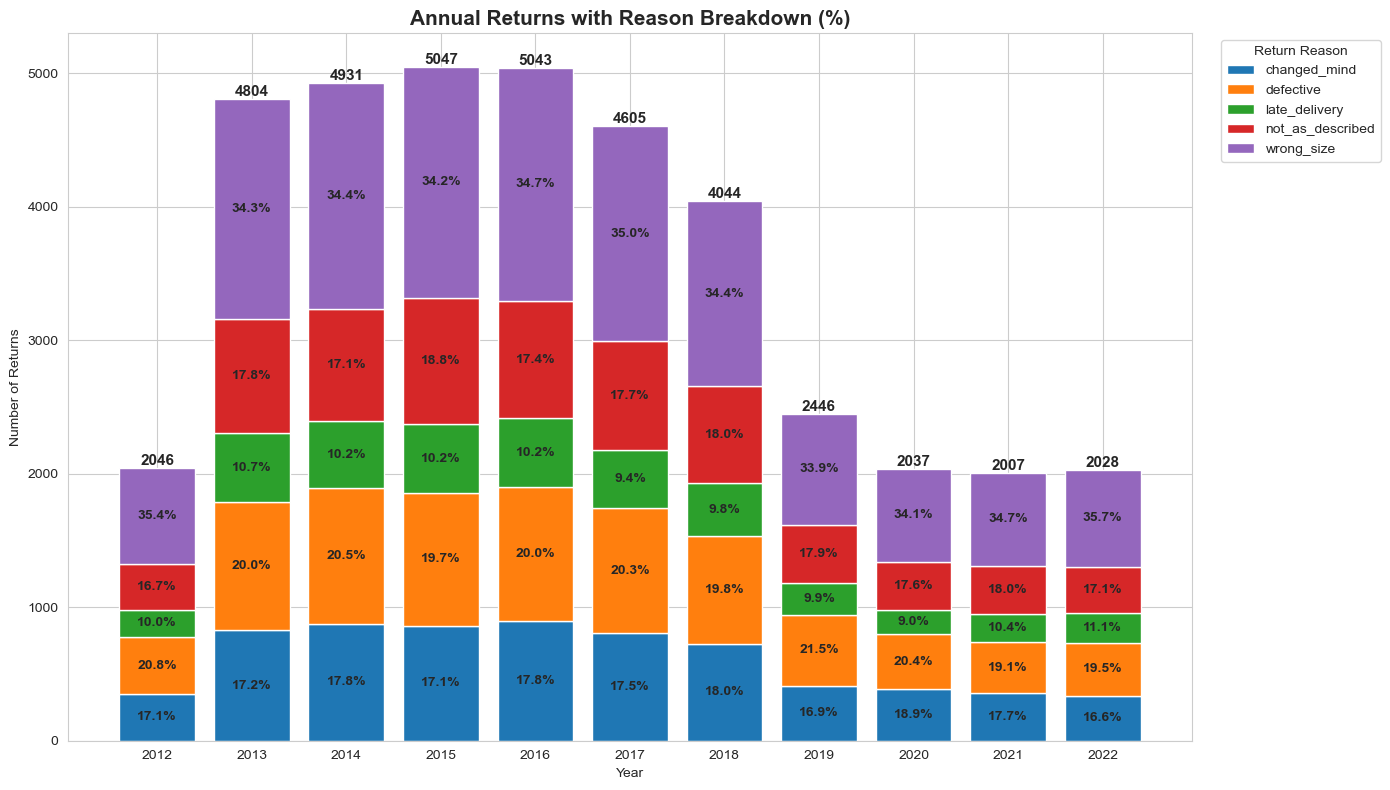

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
orders = pd.read_csv('data/orders.csv')
returns = pd.read_csv('data/returns.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

df = returns.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

df['year'] = df['order_date'].dt.year

df_unique = df[['order_id', 'year', 'return_reason']].drop_duplicates()


agg = df_unique.groupby(['year', 'return_reason']).size().reset_index(name='count')

pivot = agg.pivot(index='year', columns='return_reason', values='count').fillna(0)

total_returns = pivot.sum(axis=1)
pivot_pct = pivot.div(total_returns, axis=0) * 100

reasons = pivot.columns.tolist()

palette = sns.color_palette("tab10", len(reasons))
color_map = dict(zip(reasons, palette))

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(pivot.index))
bottom = np.zeros(len(pivot))

for col in pivot.columns:
    values = pivot[col].values
    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        color=color_map[col], 
        label=col,
        edgecolor='white'
    )

    pct_vals = pivot_pct[col].values
    for j, (bar, pct) in enumerate(zip(bars, pct_vals)):
        if pct > 3:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom[j] + values[j]/2,
                f"{pct:.1f}%",
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold'
            )

    bottom += values

for i, total in enumerate(total_returns):
    ax.text(i, total, f"{int(total)}",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index.astype(int))

ax.set_xlabel("Year")
ax.set_ylabel("Number of Returns")
ax.set_title("Annual Returns with Reason Breakdown (%)", fontsize=15, fontweight='bold')

ax.legend(title="Return Reason", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 8. Số lượng promotions qua các năm

#### 8.1 Tổng quan promo

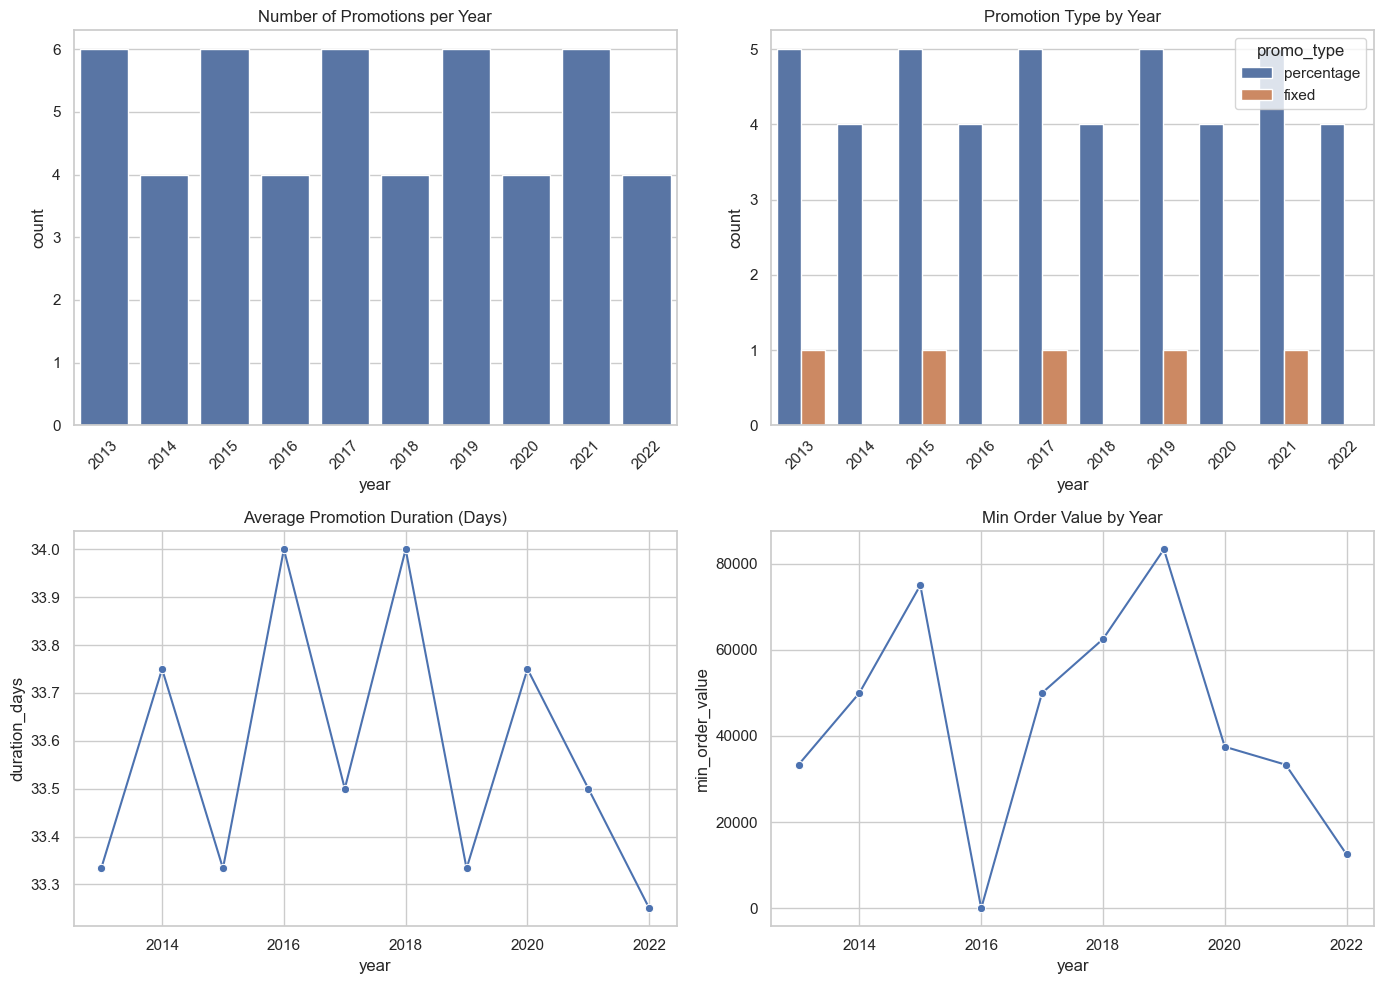

In [10]:
# ===== Promotion Analysis & Visualization =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
promo = pd.read_csv('data/promotions.csv')

# Preprocess
promo['start_date'] = pd.to_datetime(promo['start_date'])
promo['end_date'] = pd.to_datetime(promo['end_date'])

promo['year'] = promo['start_date'].dt.year
promo['duration_days'] = (promo['end_date'] - promo['start_date']).dt.days

# Split by type
percent = promo[promo['promo_type'] == 'percentage']
fixed = promo[promo['promo_type'] == 'fixed']

# ===== Set style =====
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ===== 1. Campaign count per year =====
sns.countplot(data=promo, x='year', ax=axes[0,0])
axes[0,0].set_title('Number of Promotions per Year')
axes[0,0].tick_params(axis='x', rotation=45)

# ===== 2. Promotion type distribution =====
sns.countplot(data=promo, x='year', hue='promo_type', ax=axes[0,1])
axes[0,1].set_title('Promotion Type by Year')
axes[0,1].tick_params(axis='x', rotation=45)

# ===== 3. Duration trend =====
sns.lineplot(data=promo.groupby('year')['duration_days'].mean().reset_index(),
             x='year', y='duration_days', marker='o', ax=axes[1,0])

axes[1,0].set_title('Average Promotion Duration (Days)')

# ===== 4. Min order value =====
mov = promo.groupby('year')['min_order_value'].mean().reset_index()

sns.lineplot(data=mov, x='year', y='min_order_value', marker='o', ax=axes[1,1])
axes[1,1].set_title('Min Order Value by Year')

# Layout
plt.tight_layout()
plt.show()

Việc nhìn tổng quan promotion theo năm không nói lên được gì nhiều, bởi số lượng là gần như không đổi và có tính chu kỳ, năm chẵn-lẻ

Vì vậy ta sẽ tiến hành xem thử liệu các promotions này có thực sự hiểu quả hay không

#### 8.2 Promo và revenue mà nó đem lại

- Sau khi lọc, ta thấy không có order nào sử dụng >1 promotion, đồng nghĩa với không thời điểm nào trong năm có >1 promotion diễn ra cùng lúc
- Ta sẽ tính revenue ứng với từng promo như, sau với mỗi order có promo:
    - gross_value = quantity * unit_price
    - net_revenue = gross_value - discount_amount

C:\Users\nguye\AppData\Local\Temp\ipykernel_5556\1299953031.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('data/order_items.csv')


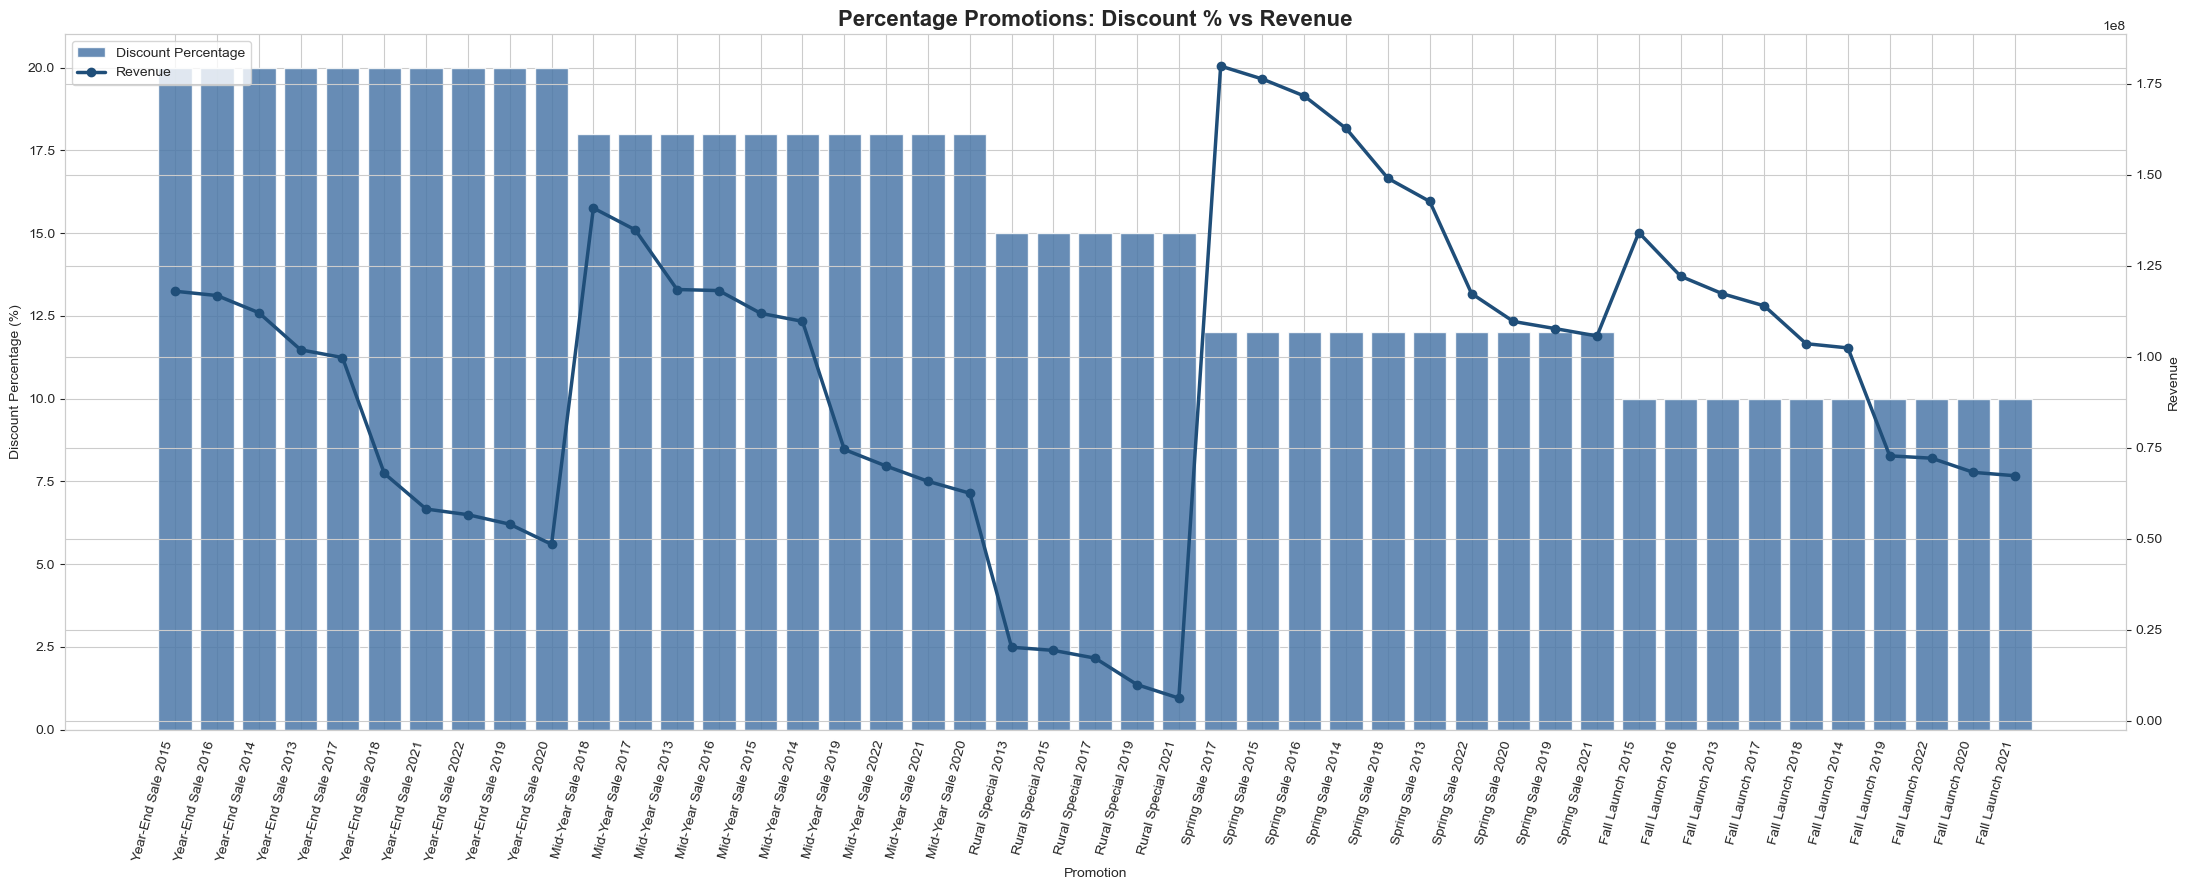

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
promo = pd.read_csv('data/promotions.csv')
order_items = pd.read_csv('data/order_items.csv')

df = order_items[
    order_items['promo_id'].notna() & order_items['promo_id_2'].isna()
].copy()

df = df.merge(
    promo[['promo_id', 'promo_name', 'promo_type', 'discount_value']],
    on='promo_id',
    how='left'
)

df = df[df['promo_type'] == 'percentage'].copy()

df['gross_value'] = df['quantity'] * df['unit_price']
df['net_revenue'] = df['gross_value'] - df['discount_amount']

promo_pct = df.groupby(['promo_name', 'discount_value'], as_index=False).agg(
    total_revenue=('net_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_items=('quantity', 'sum'),
    total_orders=('order_id', 'nunique')
)

promo_pct = promo_pct.sort_values(
    ['discount_value', 'total_revenue'],
    ascending=[False, False]
).reset_index(drop=True)

promo_pct['x'] = np.arange(len(promo_pct))

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(22, 9))
ax2 = ax1.twinx()

bar_color = '#4C78A8'
line_color = '#1F4E79'

ax1.bar(
    promo_pct['x'],
    promo_pct['discount_value'],
    color=bar_color,
    alpha=0.85,
    label='Discount Percentage'
)

ax2.plot(
    promo_pct['x'],
    promo_pct['total_revenue'],
    color=line_color,
    marker='o',
    linewidth=2.5,
    label='Revenue'
)

ax1.set_xticks(promo_pct['x'])
ax1.set_xticklabels(promo_pct['promo_name'], rotation=75, ha='right')

ax1.set_xlabel('Promotion')
ax1.set_ylabel('Discount Percentage (%)')
ax2.set_ylabel('Revenue')

ax1.set_title(
    'Percentage Promotions: Discount % vs Revenue',
    fontsize=16,
    fontweight='bold'
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\nguye\AppData\Local\Temp\ipykernel_5556\956743450.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv('data/order_items.csv')


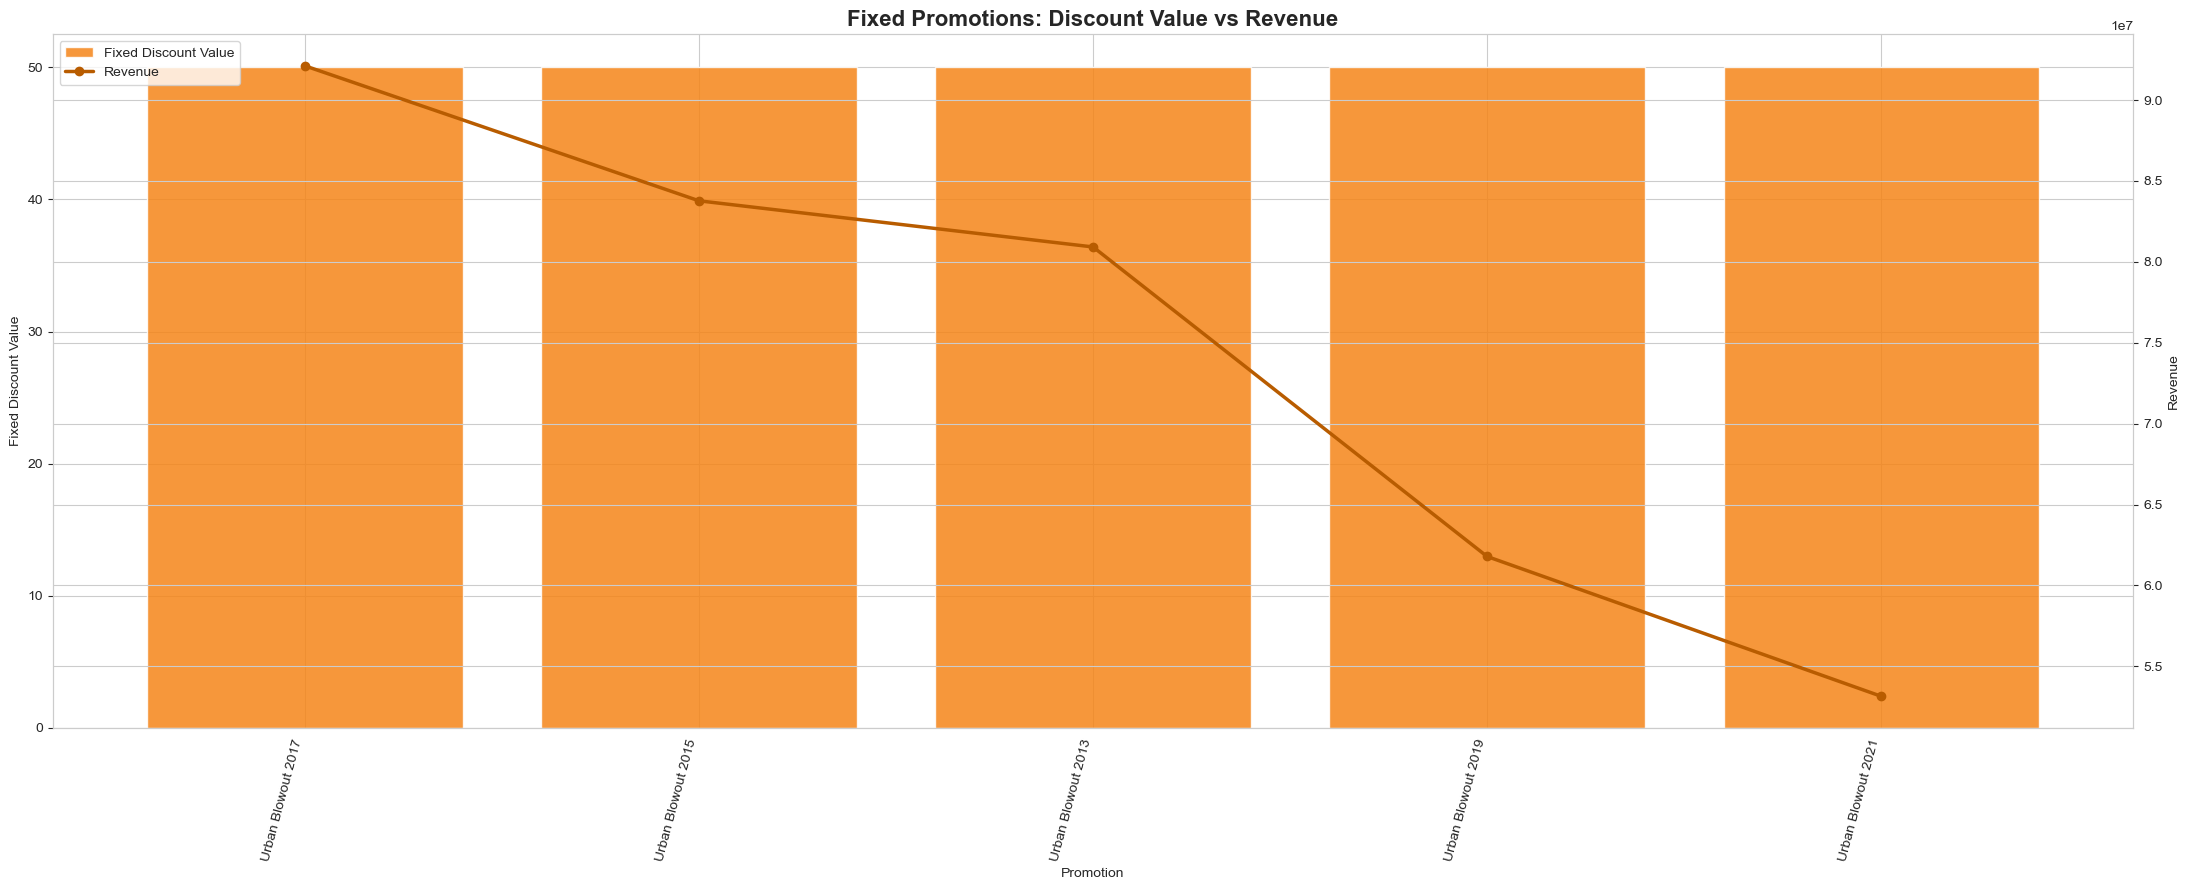

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
promo = pd.read_csv('data/promotions.csv')
order_items = pd.read_csv('data/order_items.csv')

df = order_items[
    order_items['promo_id'].notna() & order_items['promo_id_2'].isna()
].copy()

df = df.merge(
    promo[['promo_id', 'promo_name', 'promo_type', 'discount_value']],
    on='promo_id',
    how='left'
)

df = df[df['promo_type'] == 'fixed'].copy()

df['gross_value'] = df['quantity'] * df['unit_price']
df['net_revenue'] = df['gross_value'] - df['discount_amount']

promo_fixed = df.groupby(['promo_name', 'discount_value'], as_index=False).agg(
    total_revenue=('net_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_items=('quantity', 'sum'),
    total_orders=('order_id', 'nunique')
)

promo_fixed = promo_fixed.sort_values(
    ['discount_value', 'total_revenue'],
    ascending=[False, False]
).reset_index(drop=True)

promo_fixed['x'] = np.arange(len(promo_fixed))

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(22, 9))
ax2 = ax1.twinx()

bar_color = '#F58518'
line_color = '#B85C00'

ax1.bar(
    promo_fixed['x'],
    promo_fixed['discount_value'],
    color=bar_color,
    alpha=0.85,
    label='Fixed Discount Value'
)

ax2.plot(
    promo_fixed['x'],
    promo_fixed['total_revenue'],
    color=line_color,
    marker='o',
    linewidth=2.5,
    label='Revenue'
)

ax1.set_xticks(promo_fixed['x'])
ax1.set_xticklabels(promo_fixed['promo_name'], rotation=75, ha='right')

ax1.set_xlabel('Promotion')
ax1.set_ylabel('Fixed Discount Value')
ax2.set_ylabel('Revenue')

ax1.set_title(
    'Fixed Promotions: Discount Value vs Revenue',
    fontsize=16,
    fontweight='bold'
)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

### 9 Cancel orders có tăng nhiều so với các năm trước đó hay không 

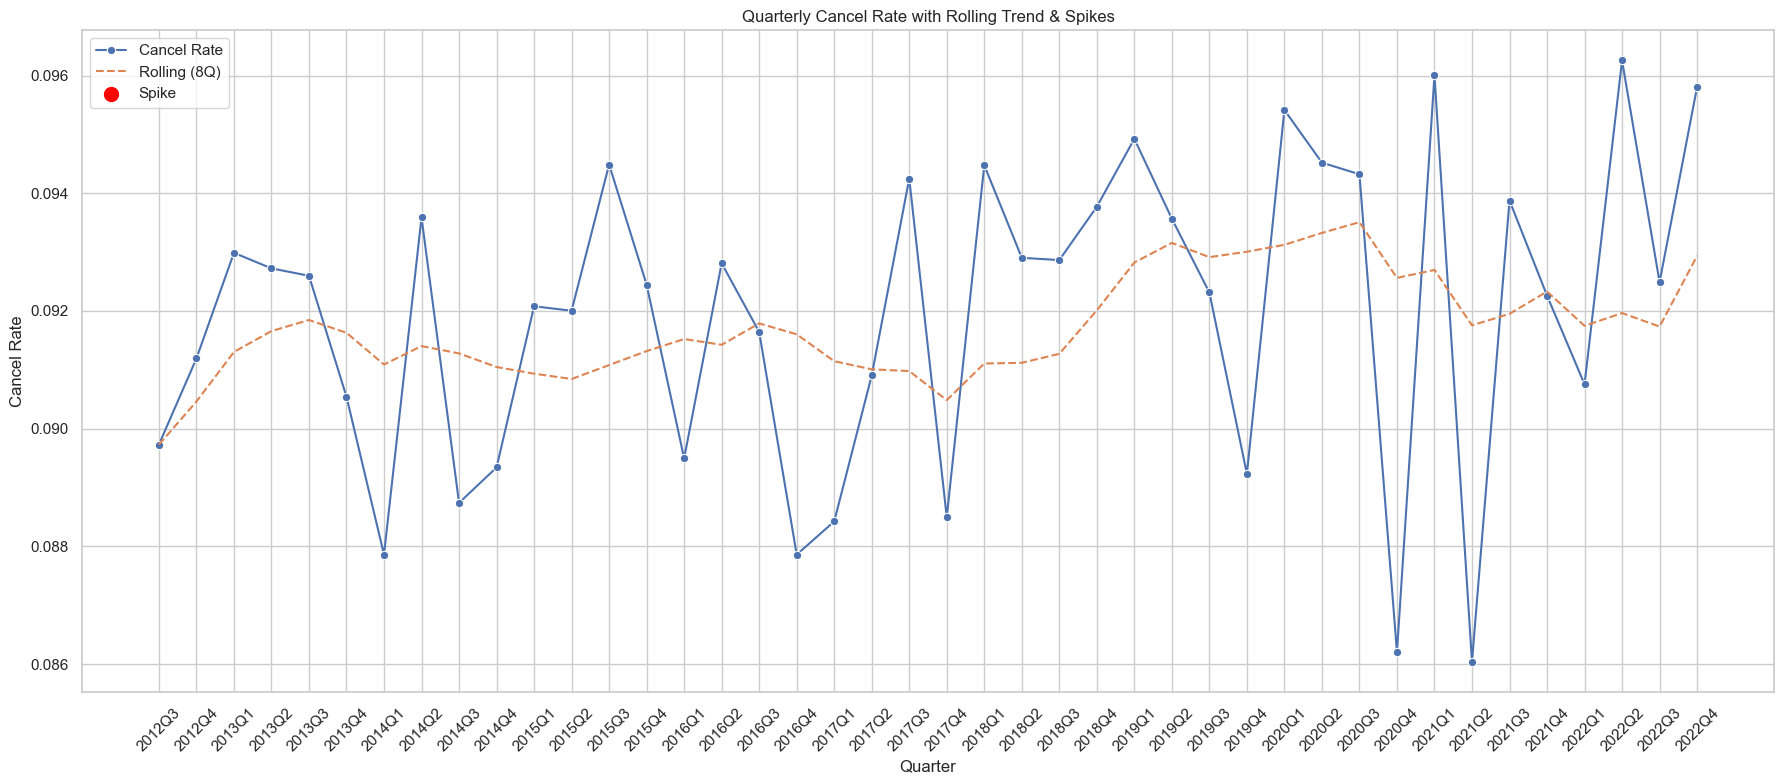

In [17]:
# ===== Cancel Order Analysis - Quarterly + Rolling + Spike =====
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('data/orders.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

# ===== Create quarter =====
orders['quarter'] = orders['order_date'].dt.to_period('Q')

# ===== Cancel filter =====
cancel_orders = orders[orders['order_status'] == 'cancelled'].copy()

# ===== Aggregate =====
quarterly_cancel = cancel_orders.groupby('quarter').size().rename('cancel_count')
quarterly_total = orders.groupby('quarter').size().rename('total_orders')

quarterly = pd.concat([quarterly_cancel, quarterly_total], axis=1).fillna(0)
quarterly['cancel_rate'] = quarterly['cancel_count'] / quarterly['total_orders']

# Sort index (important)
quarterly = quarterly.sort_index()

# ===== Rolling trend (8 quý) =====
quarterly['cancel_rate_smooth'] = quarterly['cancel_rate'].rolling(window=8, min_periods=1).mean()

# ===== Spike detection =====
quarterly['pct_change'] = quarterly['cancel_rate'].pct_change()

# Define spike threshold (bạn có thể chỉnh)
threshold = 0.3  # tăng >30% là spike
quarterly['spike'] = quarterly['pct_change'] > threshold

# Reset index để plot
quarterly = quarterly.reset_index()
quarterly['quarter_str'] = quarterly['quarter'].astype(str)

# ===== Visualization =====
sns.set_style("whitegrid")
plt.figure(figsize=(18,8))

# Main line
sns.lineplot(data=quarterly, x='quarter_str', y='cancel_rate', marker='o', label='Cancel Rate')

# Rolling line
sns.lineplot(data=quarterly, x='quarter_str', y='cancel_rate_smooth', linestyle='--', label='Rolling (8Q)')

# Highlight spikes
spikes = quarterly[quarterly['spike']]

plt.scatter(spikes['quarter_str'], spikes['cancel_rate'], 
            color='red', s=100, label='Spike')

# Annotate spikes
for i, row in spikes.iterrows():
    plt.text(i, row['cancel_rate'], f"{row['pct_change']:.1%}", color='red')

plt.title('Quarterly Cancel Rate with Rolling Trend & Spikes')
plt.xlabel('Quarter')
plt.ylabel('Cancel Rate')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Từ biểu đồ có thể thấy trong tất cả khoảng thời gian doanh nghiệp hoạt động *cancel_rate* luôn ở mức 8.6% đến 9.6%, chúng ta cùng xem số lượng đơn hàng theo từng quý như thế nào ?

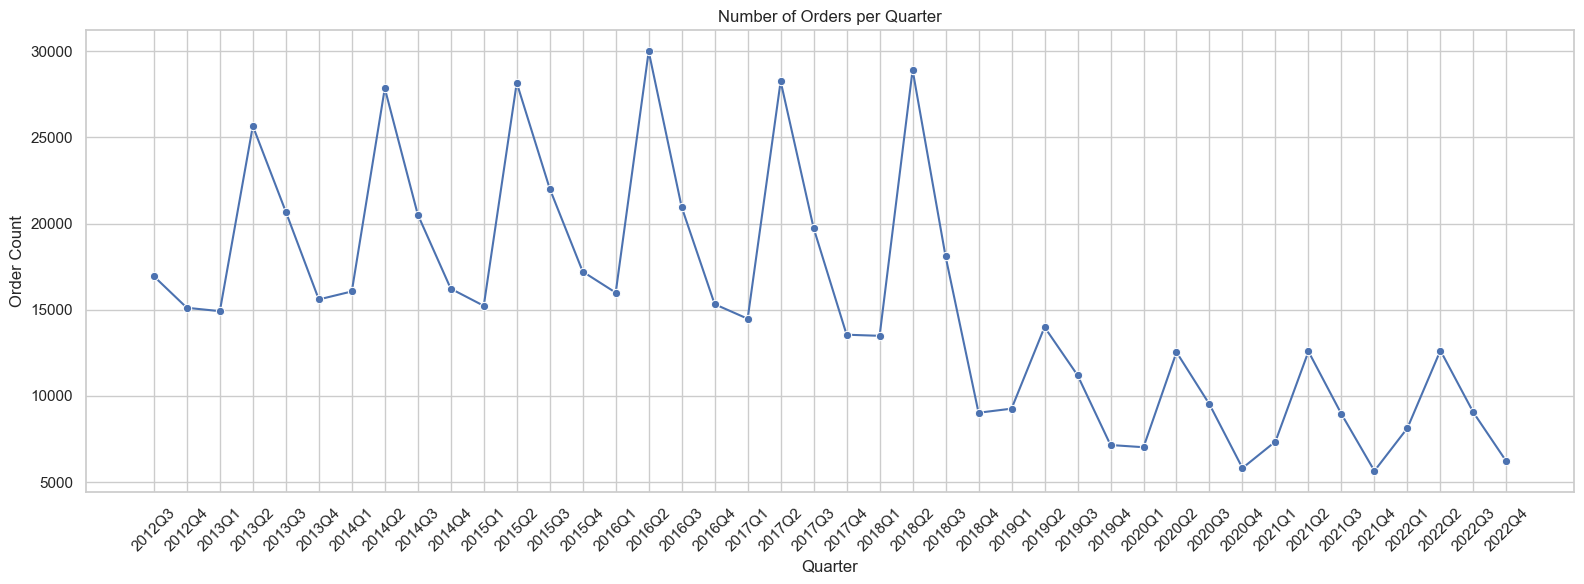

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
orders = pd.read_csv('data/orders.csv')

# Parse date
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Tạo cột quarter
orders['quarter'] = orders['order_date'].dt.to_period('Q')

# Aggregate
quarterly_orders = orders.groupby('quarter').size().reset_index(name='order_count')

# Sort đúng thứ tự thời gian
quarterly_orders = quarterly_orders.sort_values('quarter')
quarterly_orders['quarter_str'] = quarterly_orders['quarter'].astype(str)

# ===== Visualization =====
sns.set_style("whitegrid")
plt.figure(figsize=(16,6))

sns.lineplot(data=quarterly_orders, x='quarter_str', y='order_count', marker='o')

plt.title('Number of Orders per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Order Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Từ biểu đồ có thể thấy số lượng order theo quý là rất cao, thấp nhất 5000 cao nhất 30000 nhưng tỉ lệ cancel lại nhảy từ 8.6%-9.6% tức là từ 430-2580 đơn hàng bị cancel -> Một con số không hề nhỏ